In [1]:
#Imoorting Necessary Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
#Loading the Data Sets
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")



#### VIEWING THE COLUMN NAMES OF THE DATA TO GET AN UNDERSTANDING OF HOW TO MERGE THEM INTO ONE DATA SET


In [3]:
for name, df in {
    "orders": orders,
    "customers": customers,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": category_translation
}.items():
    print(f"\n{name.upper()}")
    print(df.columns)


ORDERS
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

CUSTOMERS
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

ORDER_ITEMS
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

PAYMENTS
Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

REVIEWS
Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')

PRODUCTS
Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'produ

In [5]:
#DETECTING OVERLAPS

from itertools import combinations

dfs = {
    "orders": orders,
    "customers": customers,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers
}

for (name1, df1), (name2, df2) in combinations(dfs.items(), 2):
    common = set(df1.columns).intersection(set(df2.columns))
    if common:
        print(f"{name1} ↔ {name2}: {common}")

orders ↔ customers: {'customer_id'}
orders ↔ order_items: {'order_id'}
orders ↔ payments: {'order_id'}
orders ↔ reviews: {'order_id'}
order_items ↔ payments: {'order_id'}
order_items ↔ reviews: {'order_id'}
order_items ↔ products: {'product_id'}
order_items ↔ sellers: {'seller_id'}
payments ↔ reviews: {'order_id'}


In [6]:
df = order_items.copy()

# Add orders
df = df.merge(orders, on="order_id", how="left")

# Add customers
df = df.merge(customers, on="customer_id", how="left")

# Add products
df = df.merge(products, on="product_id", how="left")

# Add category translation
df = df.merge(category_translation, on="product_category_name", how="left")

# Add sellers
df = df.merge(sellers, on="seller_id", how="left")

# Add payments
df = df.merge(payments, on="order_id", how="left")

# Add reviews
df = df.merge(reviews, on="order_id", how="left")

### 1. DATA VIEW 

In [9]:
df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,1.0,credit_card,2.0,72.19,97ca439bc427b48bc1cd7177abe71365,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,1.0,credit_card,3.0,259.83,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,1.0,credit_card,5.0,216.87,0c5b33dea94867d1ac402749e5438e8b,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,1.0,credit_card,2.0,25.78,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,2018-08-15 00:00:00,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,1.0,credit_card,3.0,218.04,940144190dcba6351888cafa43f3a3a5,5.0,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118310 entries, 0 to 118309
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118310 non-null  object 
 1   order_item_id                  118310 non-null  int64  
 2   product_id                     118310 non-null  object 
 3   seller_id                      118310 non-null  object 
 4   shipping_limit_date            118310 non-null  object 
 5   price                          118310 non-null  float64
 6   freight_value                  118310 non-null  float64
 7   customer_id                    118310 non-null  object 
 8   order_status                   118310 non-null  object 
 9   order_purchase_timestamp       118310 non-null  object 
 10  order_approved_at              118295 non-null  object 
 11  order_delivered_carrier_date   117056 non-null  object 
 12  order_delivered_customer_date 

In [12]:
df.shape

(118310, 40)

## 2. Missing Values Analysis

In [13]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
}).sort_values(by="Percentage", ascending=False)

missing_df

,Missing Values,Percentage
review_comment_title,104418,88.257966
review_comment_message,68628,58.006931
order_delivered_customer_date,2588,2.187474
product_category_name_english,1734,1.465641
product_name_lenght,1709,1.444510
product_category_name,1709,1.444510
product_photos_qty,1709,1.444510
product_description_lenght,1709,1.444510
order_delivered_carrier_date,1254,1.059927
review_score,978,0.826642


## 3. Duplicates Check

In [14]:
df.duplicated().sum()

np.int64(0)

## 4. Data Types & Conversion

In [15]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118310 entries, 0 to 118309
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       118310 non-null  object        
 1   order_item_id                  118310 non-null  int64         
 2   product_id                     118310 non-null  object        
 3   seller_id                      118310 non-null  object        
 4   shipping_limit_date            118310 non-null  object        
 5   price                          118310 non-null  float64       
 6   freight_value                  118310 non-null  float64       
 7   customer_id                    118310 non-null  object        
 8   order_status                   118310 non-null  object        
 9   order_purchase_timestamp       118310 non-null  datetime64[ns]
 10  order_approved_at              118295 non-null  object        
 11  

## 5. Descriptive Statistics

In [17]:
df.describe()

,order_item_id,price,freight_value,order_purchase_timestamp,order_delivered_customer_date,customer_zip_code_prefix,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,payment_sequential,payment_installments,payment_value,review_score
count,118310.000000,118310.000000,118310.000000,118310,115722,118310.000000,116601.000000,116601.000000,116601.000000,118290.000000,118290.000000,118290.000000,118290.000000,118310.000000,118307.000000,118307.000000,118307.000000,117332.000000
mean,1.196543,120.646603,20.032387,2017-12-30 06:31:38.646944768,2018-01-12 20:55:38.199616768,35050.658693,48.767498,785.967822,2.205161,2112.250740,30.265145,16.619706,23.074799,24442.410413,1.094069,2.943317,172.575102,4.031390
min,1.000000,0.850000,0.000000,2016-09-04 21:15:19,2016-10-11 13:46:32,1003.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000,1.000000,0.000000,0.000000,1.000000
25%,1.000000,39.900000,13.080000,2017-09-11 15:08:33.750000128,2017-09-22 21:54:31.249999872,11310.000000,42.000000,346.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000,1.000000,1.000000,60.850000,4.000000
50%,1.000000,74.900000,16.280000,2018-01-17 22:38:25.500000,2018-02-01 03:17:55,24275.500000,52.000000,600.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13660.000000,1.000000,2.000000,108.200000,5.000000
75%,1.000000,134.900000,21.180000,2018-05-03 16:34:57,2018-05-15 00:08:31.500000,58636.250000,57.000000,983.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,27972.000000,1.000000,4.000000,189.260000,5.000000
max,21.000000,6735.000000,409.680000,2018-09-03 09:06:57,2018-10-17 13:22:46,99990.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000,29.000000,24.000000,13664.080000,5.000000
std,0.699489,184.109691,15.836850,NaN,NaN,29824.585904,10.033540,652.584121,1.717452,3786.695111,16.189367,13.453584,11.749139,27573.004511,0.728579,2.777877,267.110727,1.387994


In [18]:
#For Categorical 
df.describe(include='object')


,order_id,product_id,seller_id,shipping_limit_date,customer_id,order_status,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date,customer_unique_id,...,product_category_name,product_category_name_english,seller_city,seller_state,payment_type,review_id,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,118310,118310,118310,118310,118310,118310,118295,117056,118310,118310,...,116601,116576,118310,118310,118307,117332,13892,49682,117332,117332
unique,98666,32951,3095,93318,98666,7,90174,81017,450,95420,...,73,71,611,23,4,97709,4497,35692,633,97547
top,895ab968e7bb0d5659d16cd74cd1650c,aca2eb7d00ea1a7b8ebd4e68314663af,4a3ca9315b744ce9f8e9374361493884,2017-08-14 20:43:31,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-12-20 00:00:00,9a736b248f67d166d2fbb006bcb877c3,...,cama_mesa_banho,bed_bath_table,sao paulo,SP,credit_card,eef5dbca8d37dfce6db7d7b16dd0525e,Recomendo,Muito bom,2017-12-19 00:00:00,2017-08-17 22:17:55
freq,63,536,2155,63,63,115723,63,63,656,75,...,11988,11988,29293,84377,87258,63,494,259,542,63


## 6. UNIVARIATE ANALYSIS

## Orders Over Time

<Axes: title={'center': 'Orders Over Time'}, xlabel='year_month'>

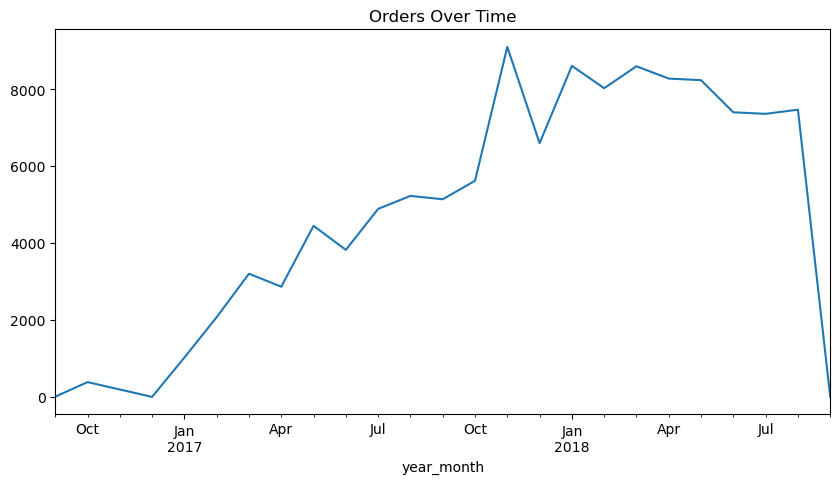

In [19]:
df["year_month"] = df["order_purchase_timestamp"].dt.to_period("M")

orders_trend = df.groupby("year_month")["order_id"].count()
orders_trend.plot(figsize=(10,5), title="Orders Over Time")


<Axes: >

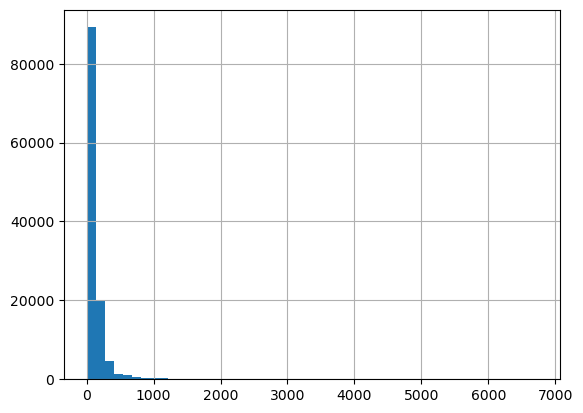

In [20]:
df["price"].hist(bins=50)

## Top Product Categories

In [21]:
df["product_category_name_english"].value_counts().head(10)

product_category_name_english
bed_bath_table           11988
health_beauty            10032
sports_leisure            9004
furniture_decor           8832
computers_accessories     8150
housewares                7380
watches_gifts             6213
telephony                 4726
garden_tools              4590
auto                      4400
Name: count, dtype: int64

## 7. BIVARIATE ANALYSIS

## Revenue by Category

In [22]:
category_revenue = df.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False)
category_revenue.head(10)


product_category_name_english
health_beauty            1301947.97
watches_gifts            1254322.95
bed_bath_table           1107249.09
sports_leisure           1029603.88
computers_accessories     950053.69
furniture_decor           772096.17
housewares                668880.94
cool_stuff                664637.13
auto                      618395.50
garden_tools              519473.33
Name: price, dtype: float64

## Orders by State (Geography Insight)

In [23]:
df["customer_state"].value_counts()

customer_state
SP    49865
RJ    15425
MG    13718
RS     6538
PR     5988
SC     4319
BA     4068
DF     2500
GO     2453
ES     2351
PE     1901
CE     1556
MT     1128
PA     1123
MS      856
MA      849
PB      640
PI      574
RN      571
AL      462
SE      397
TO      339
RO      286
AM      172
AC       95
AP       84
RR       52
Name: count, dtype: int64

## Payment Method Analysis

In [24]:
df["payment_type"].value_counts()

payment_type
credit_card    87258
boleto         23018
voucher         6332
debit_card      1699
Name: count, dtype: int64

## 8. TIME-BASED ANALYSIS

## Monthly Revenue Trend

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='year_month'>

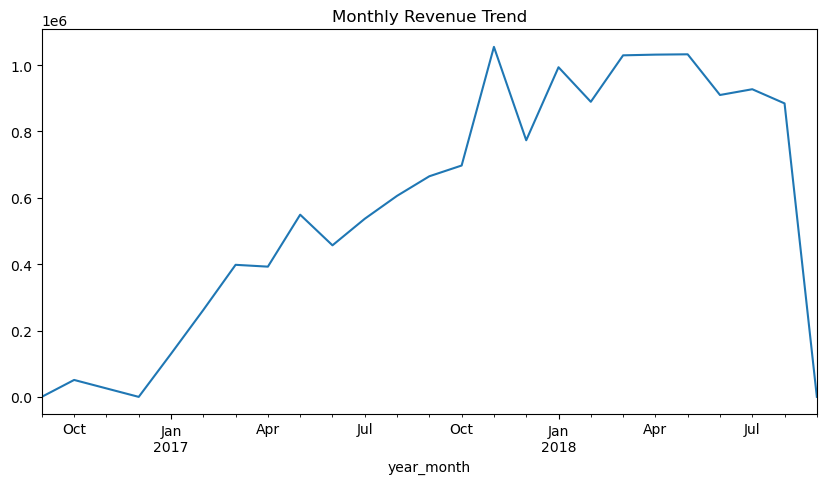

In [25]:
monthly_revenue = df.groupby("year_month")["price"].sum()
monthly_revenue.plot(figsize=(10,5), title="Monthly Revenue Trend")

## Delivery Time Analysis

In [26]:
df["delivery_time"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

df["delivery_time"].describe()

count    115722.000000
mean         12.022589
std           9.454922
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_time, dtype: float64